In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

## XRT fit

In [ ]:
from code.io import read_data, filter_data
from code.const import TRIGGER_TIME
from code.analysis import Analyzer
import numpy as np
from code.functions import power_law
from code.prior import power_law_prior

In [ ]:
df = read_data("xrt")
df = filter_data(df, exclude_time_range = (3e3,  1e4))
y_err = np.array([max(np.abs(high), np.abs(low)) for high, low in zip(df["Flux_high"], df["Flux_low"])])

alz = Analyzer(df["Time"]/3600, df["Flux"], power_law, *power_law_prior(), y_data_error=y_err)
alz.run()

In [ ]:
alz.plot_data()
alz.plot_model(color="C0")

In [ ]:
alz.plot_corner()

## i band fit

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from code.io import read_data, filter_data
from code.analysis import Analyzer
from code.functions import power_law, broken_power_law
from code.prior import power_law_prior, broken_power_law_prior
from code.utils import mag_to_flux_jy

[ultranest] Sampling 300 live points from prior ...


[ultranest] Explored until L=-2e+05  ..-178754.17 [-178754.7253..-178754.7252]*| it/evals=16560/887337 eff=1.8669% N=300  
[ultranest] Likelihood function evaluations: 888061
[ultranest]   logZ = -1.788e+05 +- 0.2587
[ultranest] Effective samples strategy satisfied (ESS = 1967.7, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.45+-0.09 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.26, need <0.5)
[ultranest]   logZ error budget: single: 0.40 bs:0.26 tail:0.01 total:0.26 required:<0.50
[ultranest] done iterating.


NameError: name 'plt' is not defined

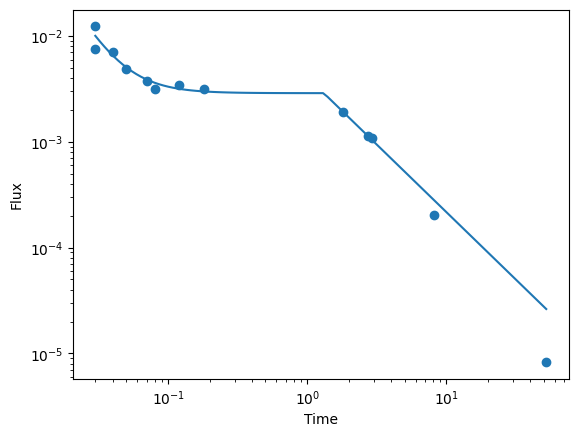

In [3]:
df = read_data("circular")
df = filter_data(df, filter_name="i")

combined_func = lambda t, *params: power_law(t, *params[:2]) + broken_power_law(t, *params[2:])

param_bounds, prior = power_law_prior()
param_bounds_bknpl, prior_bknpl = broken_power_law_prior()
param_bounds.update(param_bounds_bknpl)
prior.update(prior_bknpl)

alz = Analyzer(df["Time"], mag_to_flux_jy(df["Mag"], "i"), combined_func, param_bounds=param_bounds, prior=prior)
alz.run()


In [5]:
import matplotlib.pyplot as plt

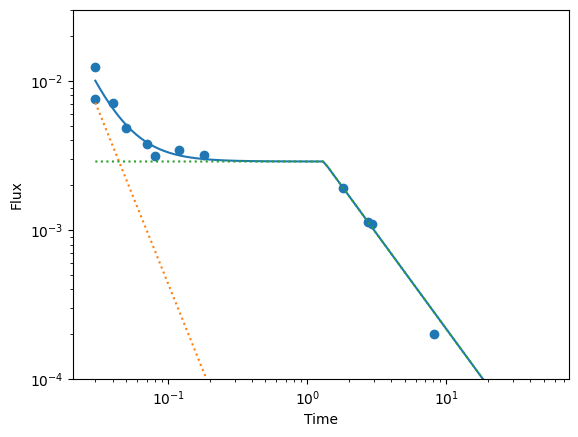

In [6]:
alz.plot_data()
alz.plot_model(color="C0")
plt.plot(alz.x_model, power_law(alz.x_model, *alz.best_fit_params[:2]), ls=":")
plt.plot(alz.x_model, broken_power_law(alz.x_model, *alz.best_fit_params[2:]), ls=":")
plt.ylim(1e-4,)
plt.show()

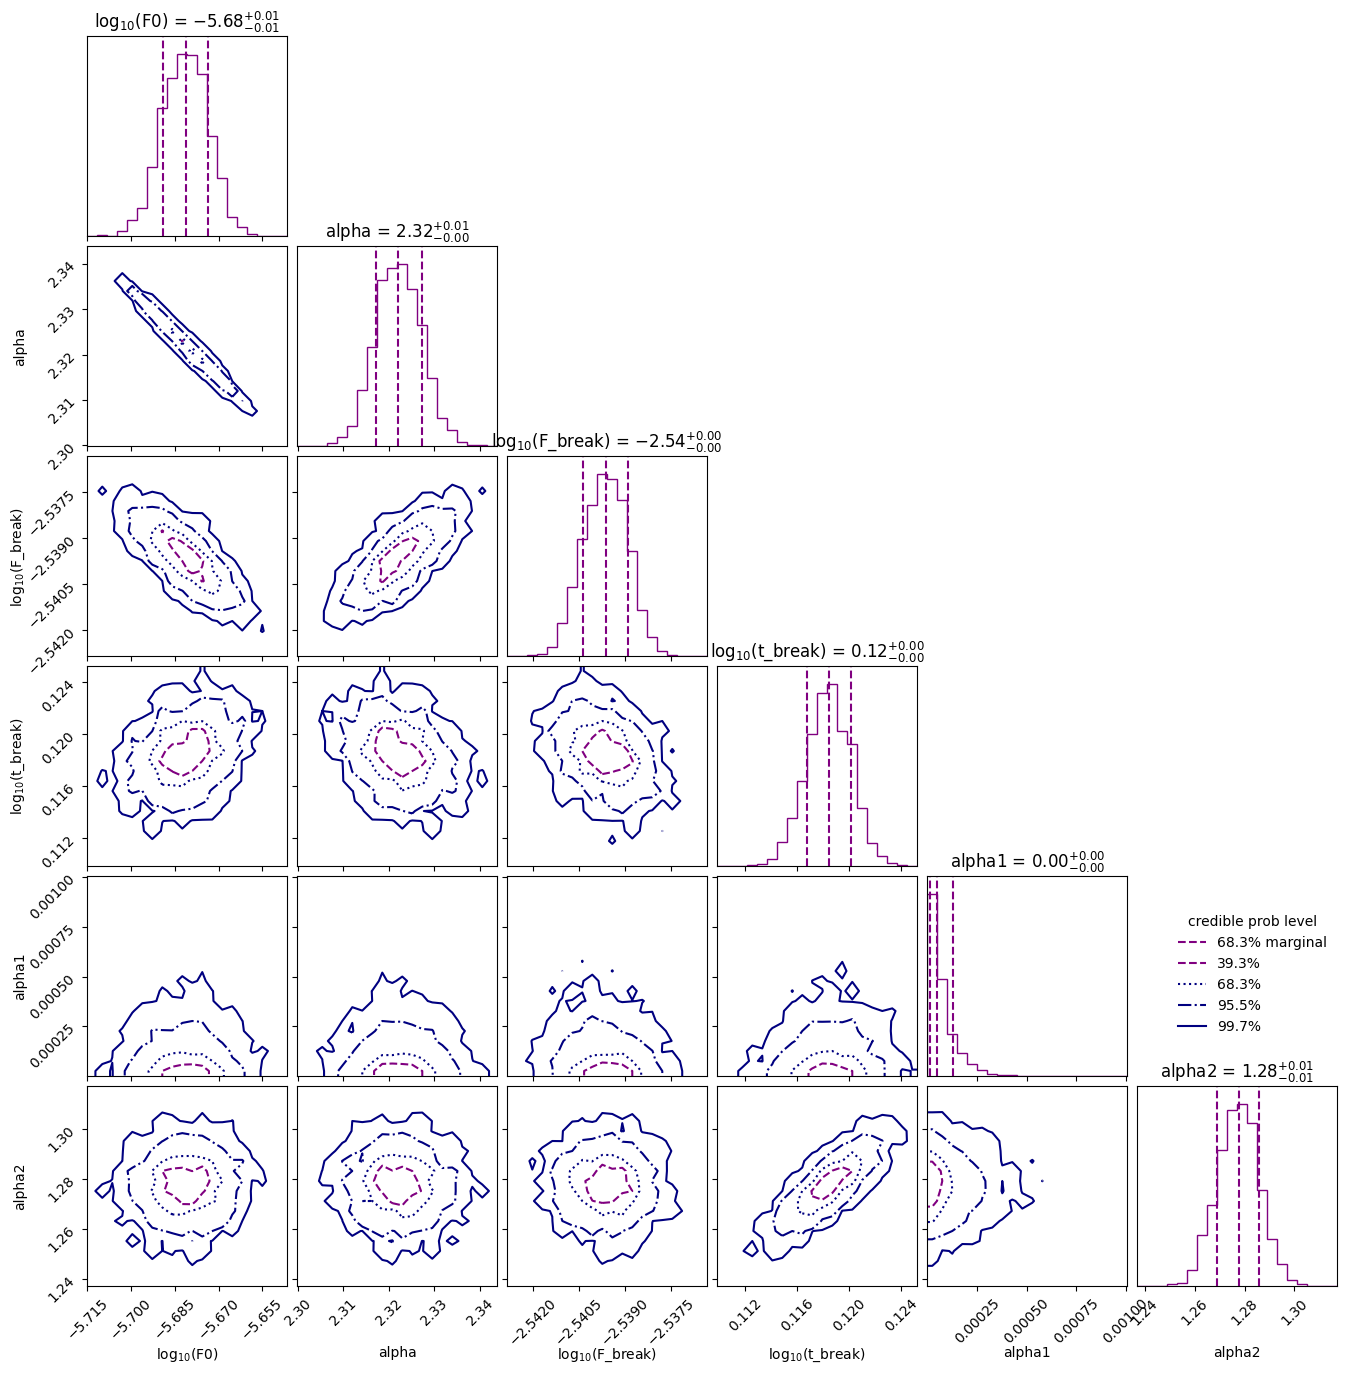

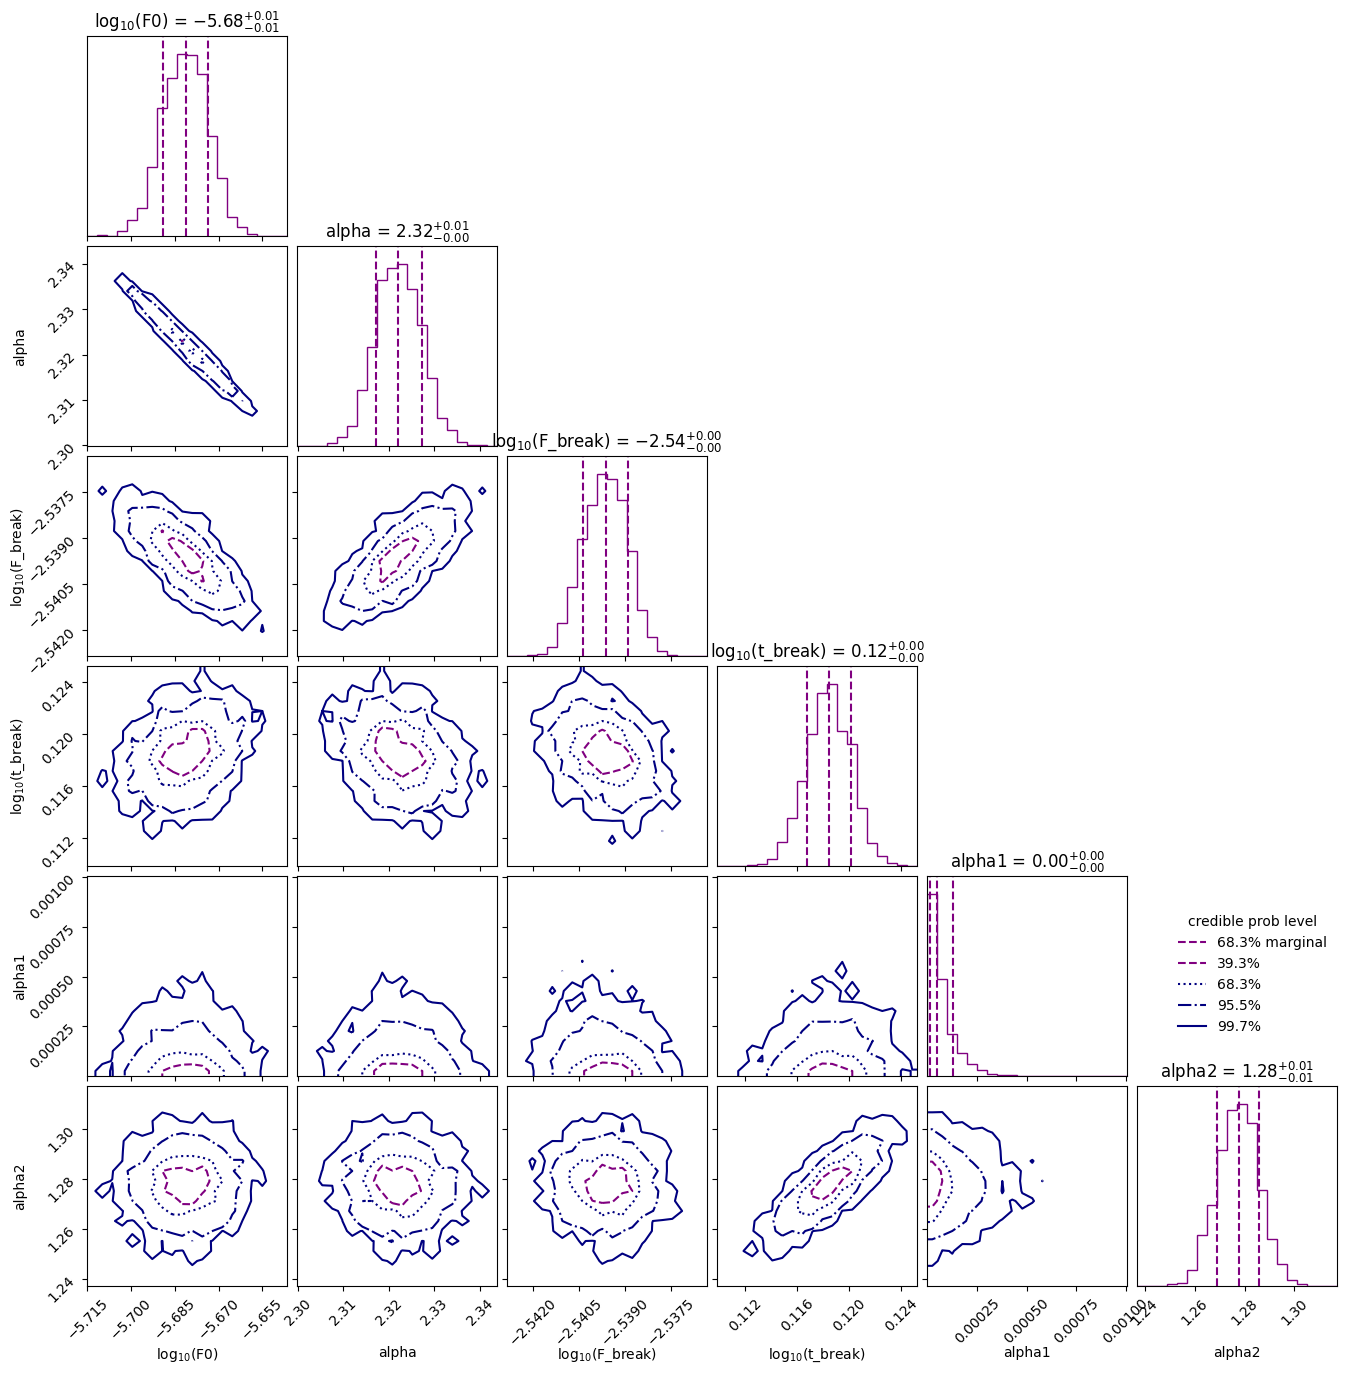

In [7]:
alz.plot_corner()